In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(f"XGBoost version: {xgb.__version__}")
print("All imports successful.")

XGBoost version: 3.1.3
All imports successful.


In [ ]:
# wherever you saved the Wind Farm A folder
base_path     = "C:/Users/cjcha/Downloads/CARE_To_Compare/CARE_To_Compare/Wind Farm A"
datasets_path = f"{base_path}/datasets"

# Load event labels
event_info = pd.read_csv(f"{base_path}/event_info.csv", sep=";")

# Load all 22 CSVs and combine
dfs = []
for fname in os.listdir(datasets_path):
    if fname.endswith(".csv"):
        df_temp             = pd.read_csv(os.path.join(datasets_path, fname), sep=";")
        df_temp["event_id"] = int(fname.replace(".csv", ""))
        dfs.append(df_temp)

df_raw = pd.concat(dfs, ignore_index=True)

# Join labels
df_raw["event_id"] = df_raw["event_id"].astype(int)
df_raw = df_raw.merge(
    event_info[["event_id", "event_label", "event_description"]],
    on="event_id", how="left"
)

# Binary label: 1 = anomaly, 0 = normal
df_raw["label"] = (df_raw["event_label"] == "anomaly").astype(int)

print(f"Rows:    {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns)}")
print(f"\nLabel distribution:")
print(df_raw["label"].value_counts())

Rows:    1,196,747
Columns: 90

Label distribution:
label
1    649789
0    546958
Name: count, dtype: int64


In [ ]:
# Same sensors as before
base_sensors = [
    # Original five
    "sensor_12_avg",    # gearbox oil temperature
    "sensor_11_avg",    # gearbox bearing temperature
    "sensor_13_avg",    # generator bearing temperature
    "sensor_18_avg",    # generator RPM
    "wind_speed_3_avg", # wind speed

    # New additions
    "sensor_41_avg",    # hydraulic group oil temperature, most common fault
    "sensor_15_avg",    # generator stator winding phase 1
    "sensor_16_avg",    # generator stator winding phase 2
    "sensor_17_avg",    # generator stator winding phase 3
    "sensor_38_avg",    # HV transformer phase L1
    "sensor_39_avg",    # HV transformer phase L2
    "sensor_40_avg",    # HV transformer phase L3
    "sensor_43_avg",    # nacelle temperature
    "sensor_52_avg",    # rotor RPM
    "power_29_avg",     # active power output
    "reactive_power_27_avg",  # reactive power
]

existing = [f for f in base_sensors if f in df_raw.columns]
missing  = [f for f in base_sensors if f not in df_raw.columns]

print(f"Base sensors found:   {existing}")
if missing:
    print(f"Base sensors missing: {missing}")

Base sensors found:   ['sensor_12_avg', 'sensor_11_avg', 'sensor_13_avg', 'sensor_18_avg', 'wind_speed_3_avg', 'sensor_41_avg', 'sensor_15_avg', 'sensor_16_avg', 'sensor_17_avg', 'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg', 'sensor_43_avg', 'sensor_52_avg', 'power_29_avg', 'reactive_power_27_avg']


In [17]:
# Split BEFORE engineering so rolling windows never cross the boundary
train_df = df_raw[df_raw["train_test"] == "train"].copy()
pred_df  = df_raw[df_raw["train_test"] == "prediction"].copy()

print(f"Training rows:   {len(train_df):,}")
print(f"Prediction rows: {len(pred_df):,}")
print(f"\nTraining anomaly rate: {train_df['label'].mean()*100:.1f}%")

Training rows:   1,146,154
Prediction rows: 50,593

Training anomaly rate: 54.6%


In [18]:
# Same feature engineering as previous notebooks

def engineer_features(df, feature_cols):
    """Add rolling, delta and z-score features per turbine per event."""
    df     = df.sort_values(["asset_id", "event_id", "time_stamp"]).copy()
    groups = df.groupby(["asset_id", "event_id"])

    for col in feature_cols:
        df[f"{col}_roll_mean_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).mean()
        )
        df[f"{col}_roll_std_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).std()
        )
        df[f"{col}_roll_mean_24h"] = groups[col].transform(
            lambda x: x.rolling(144, min_periods=1).mean()
        )
        df[f"{col}_delta"] = groups[col].transform(
            lambda x: x.diff()
        )

    return df


print("Engineering rolling and delta features...")
df_train_eng = engineer_features(train_df, existing)
df_pred_eng  = engineer_features(pred_df,  existing)

# Compute z-score baseline from training data only
print("Computing z-score baselines...")
baseline = (
    df_train_eng
    .groupby(["asset_id", "event_id"])[existing]
    .agg(["mean", "std"])
)
baseline.columns = [f"{col}_{stat}" for col, stat in baseline.columns]
baseline         = baseline.reset_index()

df_train_eng = df_train_eng.merge(baseline, on=["asset_id", "event_id"], how="left")
df_pred_eng  = df_pred_eng.merge(baseline,  on=["asset_id", "event_id"], how="left")

for col in existing:
    for df_eng in [df_train_eng, df_pred_eng]:
        df_eng[f"{col}_zscore"] = (
            (df_eng[col] - df_eng[f"{col}_mean"]) /
            df_eng[f"{col}_std"].replace(0, 1)
        )

print(f"Feature engineering complete.")
print(f"Columns after engineering: {len(df_train_eng.columns)}")

Engineering rolling and delta features...
Computing z-score baselines...
Feature engineering complete.
Columns after engineering: 202


In [19]:
engineered_features = (
    existing +
    [f"{c}_roll_mean_6h"  for c in existing] +
    [f"{c}_roll_std_6h"   for c in existing] +
    [f"{c}_roll_mean_24h" for c in existing] +
    [f"{c}_delta"         for c in existing] +
    [f"{c}_zscore"        for c in existing]
)

X_train     = df_train_eng[engineered_features].fillna(0)
y_train     = df_train_eng["label"].values
X_pred      = df_pred_eng[engineered_features].fillna(0)
y_pred_true = df_pred_eng["label"].values

print(f"Base sensors:              {len(existing)}")
print(f"Total engineered features: {len(engineered_features)}")
print(f"\nTraining rows:   {len(X_train):,}")
print(f"Prediction rows: {len(X_pred):,}")

Base sensors:              16
Total engineered features: 96

Training rows:   1,146,154
Prediction rows: 50,593


Calculates the ratio of normal to anomaly rows in the training set. XGBoost uses this as scale_pos_weight to force the model to pay equal attention to the rare anomaly class rather than ignoring it.

In [20]:
# XGBoost has a dedicated parameter called scale_pos_weight
# that handles class imbalance directly.
#
# The formula is simple:
#   scale_pos_weight = number of normal rows / number of anomaly rows
#
# If this equals 9 it means: treat each anomaly row as if it were
# 9 normal rows during training. This forces XGBoost to pay equal
# attention to both classes rather than ignoring the rare anomalies.
#
# This is more precise than Random Forest's class_weight="balanced"
# because you control the exact ratio yourself.

normal_count     = (y_train == 0).sum()
anomaly_count    = (y_train == 1).sum()
scale_pos_weight = normal_count / anomaly_count

print(f"Normal rows:       {normal_count:,}")
print(f"Anomaly rows:      {anomaly_count:,}")
print(f"Imbalance ratio:   {scale_pos_weight:.1f}:1")
print(f"scale_pos_weight:  {scale_pos_weight:.2f}")

Normal rows:       520,894
Anomaly rows:      625,260
Imbalance ratio:   0.8:1
scale_pos_weight:  0.83


In [ ]:
# XGBoost builds trees sequentially, each new tree focuses on
# correcting the mistakes made by all the previous trees combined.
# This is called gradient boosting.
#
# Key parameters:
#
# n_estimators=300
#   Number of trees to build sequentially.
#   More than Random Forest because each individual tree is simpler
#   and learns only a small correction at a time.
#
# max_depth=6
#   How deep each tree can grow. Shallower than Random Forest (10)
#   because XGBoost trees are meant to be "weak learners" that
#   each contribute a small correction — not fully grown trees.
#
# learning_rate=0.05
#   How big a correction each new tree makes.
#   Lower = more careful, more trees needed, usually more accurate.
#   Higher = faster but risks overshooting the right answer.
#   0.05 is a safe starting point.
#
# subsample=0.8
#   Each tree only sees 80% of the training rows, chosen randomly.
#   Adds variety between trees and prevents overfitting.
#
# colsample_bytree=0.8
#   Each tree only sees 80% of the features, chosen randomly.
#   Same idea, prevents any one feature dominating every tree.
#
# scale_pos_weight
#   The imbalance correction computed in Cell 7.
#
# eval_metric="aucpr"
#   How XGBoost measures its own progress during training.
#   AUC-PR (area under precision-recall curve) is the right metric
#   for imbalanced datasets

print("Training XGBoost...")
print("(Should take about 1 minute)")

xgb_model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = "aucpr",
    random_state     = 42,
    n_jobs           = -1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train)],
    verbose=50   # prints progress every 50 trees
)

print("\nTraining complete.")

Training XGBoost...
(Should take about 1 minute)
[0]	validation_0-aucpr:0.76770
[50]	validation_0-aucpr:0.94322
[100]	validation_0-aucpr:0.97791
[150]	validation_0-aucpr:0.99133
[200]	validation_0-aucpr:0.99751
[250]	validation_0-aucpr:0.99919
[299]	validation_0-aucpr:0.99959

Training complete.


In [22]:
xgb_preds = xgb_model.predict(X_pred)
xgb_probs = xgb_model.predict_proba(X_pred)[:, 1]
xgb_acc   = accuracy_score(y_pred_true, xgb_preds)

print(f"Accuracy: {xgb_acc*100:.1f}%")
print("\nDetailed breakdown:")
print(classification_report(
    y_pred_true, xgb_preds,
    target_names=["Normal (0)", "Anomaly (1)"]
))

Accuracy: 98.8%

Detailed breakdown:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99     26064
 Anomaly (1)       0.98      0.99      0.99     24529

    accuracy                           0.99     50593
   macro avg       0.99      0.99      0.99     50593
weighted avg       0.99      0.99      0.99     50593



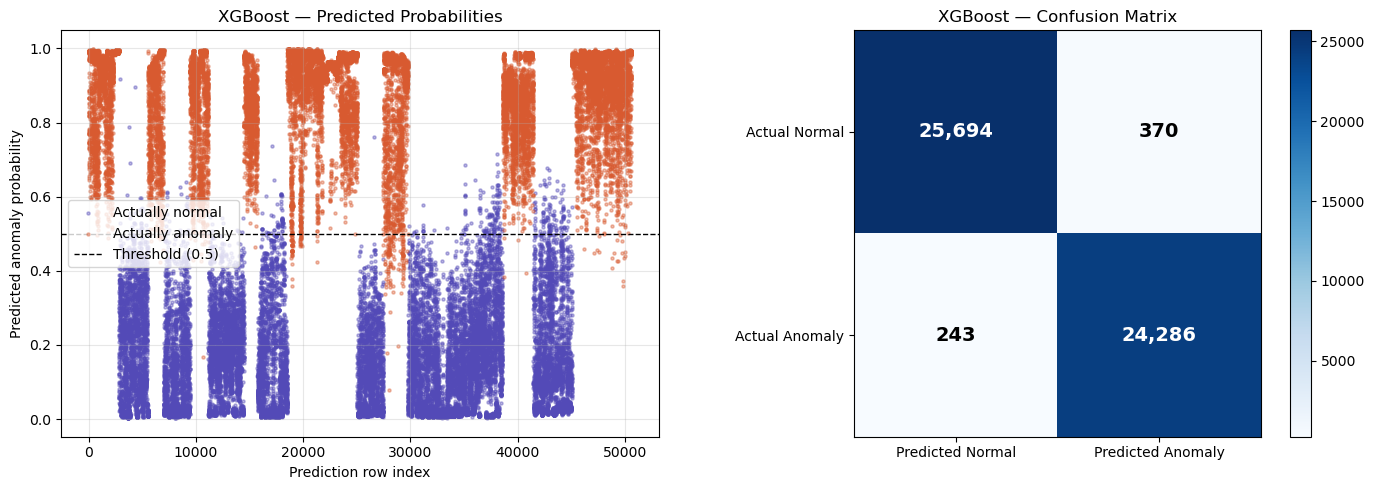


True Positives  (anomaly correctly flagged): 24,286
True Negatives  (normal correctly ignored):  25,694
False Positives (false alarms):              370
False Negatives (missed faults):             243


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_mask  = y_pred_true == 0
anomaly_mask = y_pred_true == 1

# Left — predicted probabilities
axes[0].scatter(
    np.where(normal_mask)[0],  xgb_probs[normal_mask],
    color="#534AB7", alpha=0.4, s=5, label="Actually normal"
)
axes[0].scatter(
    np.where(anomaly_mask)[0], xgb_probs[anomaly_mask],
    color="#D85A30", alpha=0.4, s=5, label="Actually anomaly"
)
axes[0].axhline(y=0.5, color="black", linestyle="--",
                linewidth=1, label="Threshold (0.5)")
axes[0].set_xlabel("Prediction row index")
axes[0].set_ylabel("Predicted anomaly probability")
axes[0].set_title("XGBoost — Predicted Probabilities")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right — confusion matrix
cm = confusion_matrix(y_pred_true, xgb_preds)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Predicted Normal", "Predicted Anomaly"])
axes[1].set_yticklabels(["Actual Normal", "Actual Anomaly"])
axes[1].set_title("XGBoost — Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, f"{cm[i,j]:,}", ha="center", va="center",
            color="white" if cm[i,j] > cm.max()/2 else "black",
            fontsize=14, fontweight="bold"
        )
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig("xgb_results.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (anomaly correctly flagged): {tp:,}")
print(f"True Negatives  (normal correctly ignored):  {tn:,}")
print(f"False Positives (false alarms):              {fp:,}")
print(f"False Negatives (missed faults):             {fn:,}")

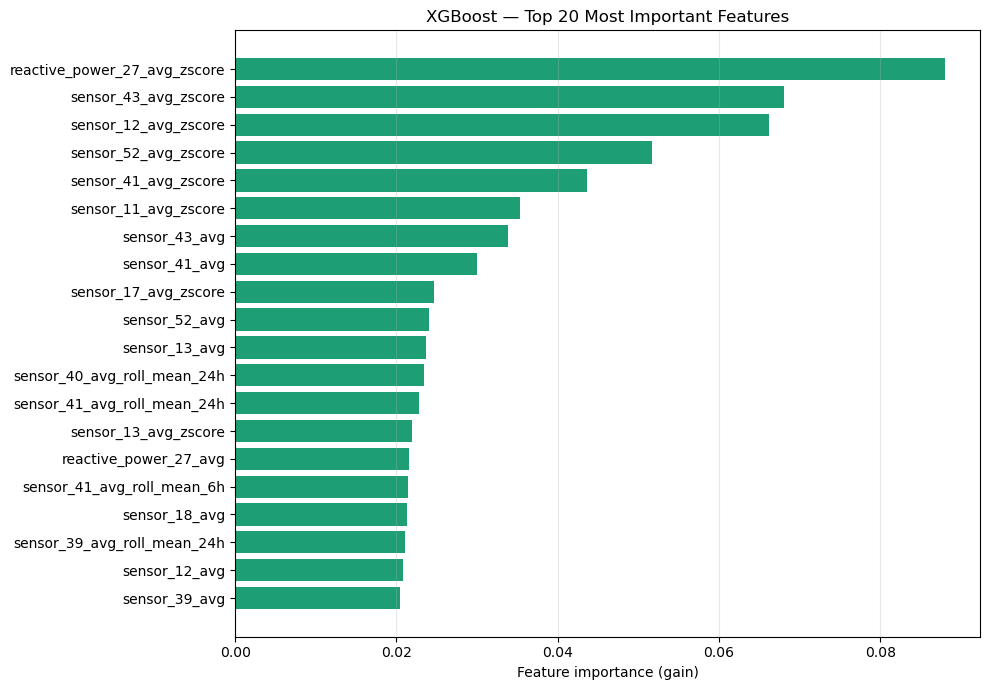

Top 10 most important features:
                     feature  importance
reactive_power_27_avg_zscore    0.087971
        sensor_43_avg_zscore    0.068109
        sensor_12_avg_zscore    0.066195
        sensor_52_avg_zscore    0.051716
        sensor_41_avg_zscore    0.043633
        sensor_11_avg_zscore    0.035356
               sensor_43_avg    0.033823
               sensor_41_avg    0.029973
        sensor_17_avg_zscore    0.024708
               sensor_52_avg    0.024060


In [ ]:
# XGBoost feature importance works the same way as Random Forest
# higher score = more useful for separating anomalies from normal.
#
# One difference: XGBoost gives you three types of importance.
# We use "gain" which measures how much each feature actually improved
# predictions, not just how often it was used.
# gain is more meaningful than weight (frequency of use) because
# a feature can be used often but contribute very little.

importance_df = pd.DataFrame({
    "feature":    engineered_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top20["feature"][::-1],
    top20["importance"][::-1],
    color="#1D9E75", edgecolor="none"
)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost — Top 20 Most Important Features")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 most important features:")
print(importance_df[["feature", "importance"]].head(10).to_string(index=False))

Best event:      Event 73 — Hydraulic group
First detection: 72.0 hours before fault


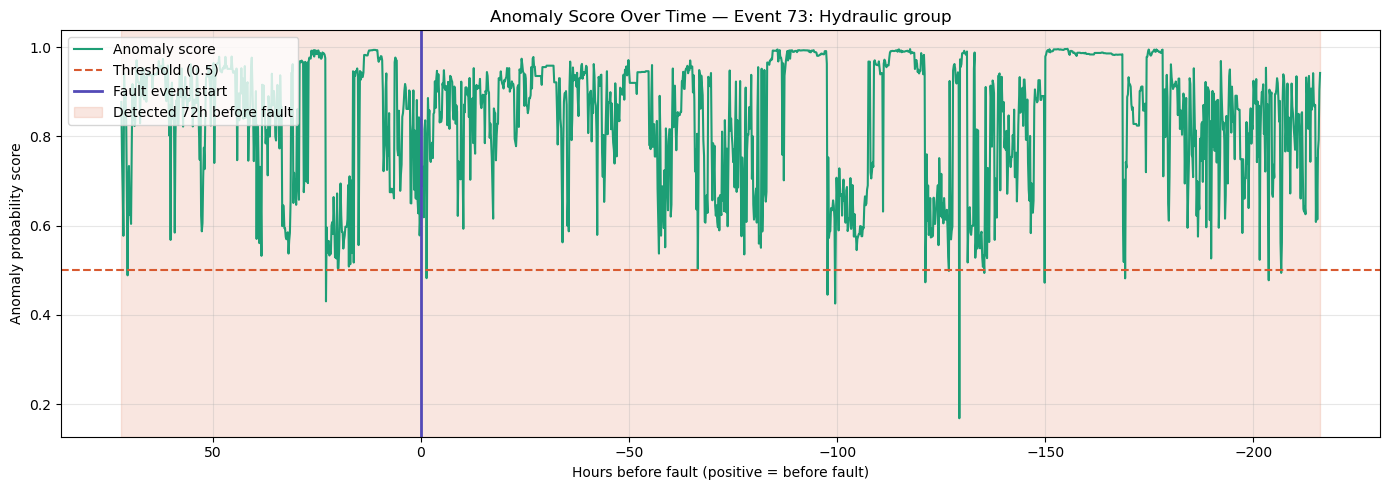

In [ ]:
pred_df_plot              = df_pred_eng.copy()
pred_df_plot["score"]     = xgb_probs
pred_df_plot["predicted"] = xgb_preds

# Load event start times only, event_label already exists in pred_df_plot
event_times                = event_info[["event_id", "event_start"]].copy()
event_times["event_start"] = pd.to_datetime(event_times["event_start"])
pred_df_plot["time_stamp"] = pd.to_datetime(pred_df_plot["time_stamp"])

pred_df_plot = pred_df_plot.merge(event_times, on="event_id", how="left")
pred_df_plot["hours_to_event"] = (
    (pred_df_plot["event_start"] - pred_df_plot["time_stamp"])
    .dt.total_seconds() / 3600
)

# Pick the anomaly event with the earliest detection
best_event_id = None
best_hours    = -999

for eid in pred_df_plot[pred_df_plot["event_label"] == "anomaly"]["event_id"].unique():
    detected = pred_df_plot[
        (pred_df_plot["event_id"] == eid) &
        (pred_df_plot["score"] >= 0.5)
    ]
    if len(detected) > 0:
        earliest = detected["hours_to_event"].max()
        if earliest > best_hours:
            best_hours    = earliest
            best_event_id = eid

if best_event_id is not None:
    event_plot = pred_df_plot[
        pred_df_plot["event_id"] == best_event_id
    ].sort_values("hours_to_event", ascending=False)

    fault_desc = event_info[
        event_info["event_id"] == best_event_id
    ]["event_description"].values[0]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        event_plot["hours_to_event"],
        event_plot["score"],
        color="#1D9E75", linewidth=1.5, label="Anomaly score"
    )
    ax.axhline(y=0.5, color="#D85A30", linestyle="--",
               linewidth=1.5, label="Threshold (0.5)")
    ax.axvline(x=0, color="#534AB7", linestyle="-",
               linewidth=2, label="Fault event start")

    detected = event_plot[event_plot["score"] >= 0.5]
    if len(detected) > 0:
        first_detection = detected["hours_to_event"].max()
        ax.axvspan(
            detected["hours_to_event"].min(),
            detected["hours_to_event"].max(),
            alpha=0.15, color="#D85A30",
            label=f"Detected {first_detection:.0f}h before fault"
        )
        print(f"Best event:      Event {best_event_id} — {fault_desc}")
        print(f"First detection: {first_detection:.1f} hours before fault")
    else:
        print("No detections — try lowering threshold to 0.3")

    ax.set_xlabel("Hours before fault (positive = before fault)")
    ax.set_ylabel("Anomaly probability score")
    ax.set_title(f"Anomaly Score Over Time — Event {best_event_id}: {fault_desc}")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
    plt.tight_layout()
    plt.savefig("xgb_anomaly_timeseries.png", dpi=150, bbox_inches="tight")
    plt.show()
    # print("Plot saved as xgb_anomaly_timeseries.png")
else:
    print("No detections found — try lowering threshold to 0.3")

In [29]:
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

tn, fp, fn, tp = cm.ravel()
xgb_precision  = tp / max(tp + fp, 1)
xgb_recall     = tp / max(tp + fn, 1)

print(f"\n{'Metric':<35} {'XGBoost':>10}")
print("-" * 50)
print(f"{'Accuracy':<35} {xgb_acc*100:>9.1f}%")
print(f"{'Precision (of flags, % correct)':<35} {xgb_precision*100:>9.1f}%")
print(f"{'Recall (of faults, % caught)':<35} {xgb_recall*100:>9.1f}%")
print(f"{'True Positives':<35} {tp:>10,}")
print(f"{'False Positives (false alarms)':<35} {fp:>10,}")
print(f"{'False Negatives (missed faults)':<35} {fn:>10,}")

print(f"\nTop 3 most important features:")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}")

print(f"\nEarliest fault detection: {best_hours:.1f} hours before fault")

print("\nSaved plots:")
print("  xgb_results.png")
print("  xgb_feature_importance.png")
print("  xgb_anomaly_timeseries.png")
print("=" * 60)

MODEL COMPARISON SUMMARY

Metric                                 XGBoost
--------------------------------------------------
Accuracy                                 98.8%
Precision (of flags, % correct)          98.5%
Recall (of faults, % caught)             99.0%
True Positives                          24,286
False Positives (false alarms)             370
False Negatives (missed faults)            243

Top 3 most important features:
  reactive_power_27_avg_zscore        0.0880
  sensor_43_avg_zscore                0.0681
  sensor_12_avg_zscore                0.0662

Earliest fault detection: 72.0 hours before fault

Saved plots:
  xgb_results.png
  xgb_feature_importance.png
  xgb_anomaly_timeseries.png
